In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte


# Import Required Library & Load data

In [2]:
import torch
#Torchvision has inbuilt Dataset where FashionMnist dataset is available, Lets import data
# It has all functionality to work with Image data
import torchvision
import torchvision.transforms as transforms

In [3]:
# Checking availability of Cuda (NVIDEA GPU)
torch.cuda.is_available()

True

In [4]:
train_set = torchvision.datasets.FashionMNIST(
root = './data',
train = True,
download = True,
transform = transforms.Compose([transforms.ToTensor()])
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



/opt/conda/lib/python3.7/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /usr/local/src/pytorch/torch/csrc/utils/tensor_numpy.cpp:174.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


In [5]:
# Checking dataset length
len(train_set)

60000

Let's Import libraries to generate Random Subset & dataLoader to feed Batch of data to model, as feeding whole dataset may lead to System failure or Hang

In [6]:
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

We will be performing Data Normalization.
Data Normalization is technique where we normalize data using Formula (x - mu) / std. By performing Standrdization, we will reduce importance of any feature that gives equal opportunity all variables.


We can assume this value as 0.5 mean and 0.5 standard deviation, but its always best practice to find for each Dataset

# Data Study and Stadardization

Let's find out original data size and shape

In [7]:
len(train_set)

60000

In [8]:
img, label = train_set[0]
img.shape, label

(torch.Size([1, 28, 28]), 9)

So we have 60000 train data and each image is 28*28 pixel and all are gray scale as only 1 color channel exist

In [9]:
# let's view some images

In [10]:
def show_img(img, label):
    print('Label: ', label)
    plt.imshow(img.permute(1,2,0), cmap = 'gray')

In [11]:
import matplotlib.pyplot as plt

Label:  0


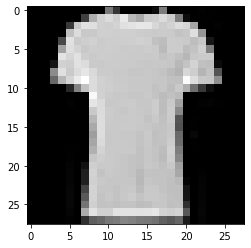

In [12]:
show_img(*train_set[5999])

Label:  5


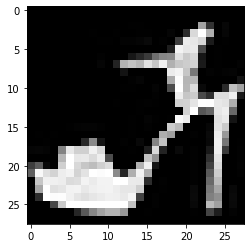

In [13]:
show_img(*train_set[9])

Following code will help us to find Mean and Standard Deviation, let's calculate

In [14]:
loader = DataLoader(train_set, batch_size = 1000, num_workers = 1)
num_pixels = len(train_set) * 28 * 28

total_sum = 0
for batch in loader:
    total_sum += batch[0].sum()
    
mean = total_sum / num_pixels

sum_squared_error = 0

for batch in loader:
    sum_squared_error += ((batch[0] - mean).pow(2)).sum()
    
std = torch.sqrt(sum_squared_error / total_sum)

mean.item(), std.item()

(0.28604066371917725, 0.6600710153579712)

So Mean = 0.286, Std = 0.66

# Regularization

Main aim is to reduce Overfitting, lets see below code

In [15]:
transform1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear = 10, scale = (0.8, 1.2)),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(0.286, 0.6601),
    #transforms.Pad(2),
    transforms.RandomHorizontalFlip(p=1)
])

Let's download Train & Test images

In [16]:
train_set1 = torchvision.datasets.FashionMNIST(
root = './data',
train = True,
download = True,
transform = transform1
)

In [17]:
test_set = torchvision.datasets.FashionMNIST(
root = './data',
train = False,
download = True,
transform = transform1
)

Lets verify how transformation has been carried out and its effect

In [18]:
img1, label = train_set1[0]

Label:  2


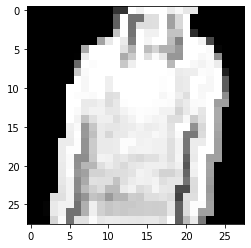

In [19]:
# this is New Image set
show_img(*train_set1[1109])

Label:  2


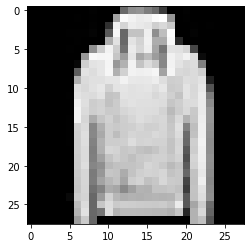

In [20]:
# This is Original image
show_img(*train_set[1109])

We can depict change in image clearly

In [21]:
img, label = train_set1[0]
img.shape, label

(torch.Size([1, 28, 28]), 9)

In [22]:
img, label = test_set[0]
img.shape, label

(torch.Size([1, 28, 28]), 9)

So images now are of size 

# Training & Validation set Generation

In [23]:
import numpy as np

Let's Import libraries to generate Random Subset & dataLoader to feed Batch of data to model, as feeding whole dataset may lead to System failure or Hang

In [24]:
def split_indices(n, val_per, seed = 0):
    n_val = int(n * val_per)
    np.random.seed(seed)
    idx = np.random.permutation(n)
    return idx[n_val : ], idx[: n_val]

In [25]:
val_per = 0.2
rand_seed = 42

train_indices, val_indices = split_indices(len(train_set1), val_per, rand_seed)

print(len(train_indices), len(val_indices))

48000 12000


In [26]:
print("Validation Indices: ", val_indices[:20])
print("Training Indices: ", train_indices[:20])

Validation Indices:  [12628 37730 39991  8525  8279 51012 14871 15127  9366 33322 53390 21819
  5026 23428 45297 26354 30195 47038 20731 34047]
Training Indices:  [48572 38696 13611 35213 31766 57477  9165 21399 44113 55436 33761  2417
 10339 21794 59625 38542 10557  4120 46651 59905]


In [27]:
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

In [28]:
# this is one of Hyper parameter, but let's select given below value
batch_size = 512

In [29]:
# training data loader
train_sampler = SubsetRandomSampler(train_indices)
train_dl = DataLoader(train_set1, batch_size, sampler = train_sampler)

In [30]:
# validation dataloader
val_sampler = SubsetRandomSampler(val_indices)
val_dl = DataLoader(train_set1, batch_size, sampler = val_sampler)

Let's verify where we have all class from output columns in both train and validation set



In [31]:
from torchvision.utils import make_grid
# this will help us to create Grid of images

In [32]:
# We will select first 110 image from first batch of size = 512
def show_batch(dl):
    for img, label in dl:
        fig, ax = plt.subplots(figsize = (12,8))
        ax.imshow(make_grid(img[:110], 10).permute(1,2,0))
        break

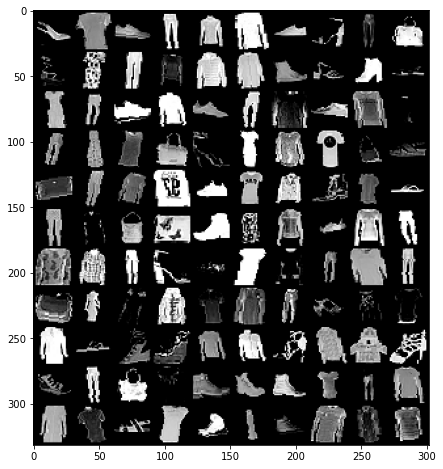

In [33]:
show_batch(val_dl)

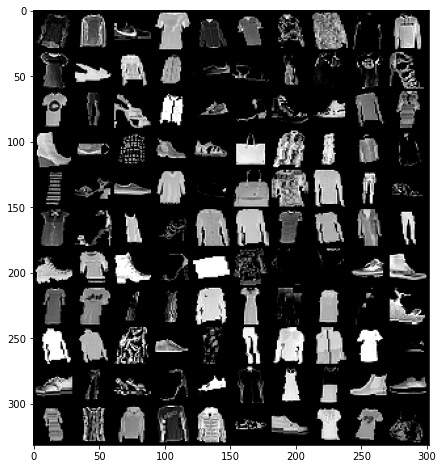

In [34]:
show_batch(train_dl)

# Model Building using Torch.nn

In [35]:
sample = next(iter(train_set1))
img = sample[0]
img.shape

torch.Size([1, 28, 28])

In [36]:
import torch.nn as nn
import torch.nn.functional as F

In [37]:
class ResidualBlock(nn.Module):
    
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        
        self.block = nn.Sequential(
                nn.Conv2d(in_channels = channels[0], out_channels = channels[1], kernel_size = (3,3), stride = (2,2), padding = 1),
                nn.BatchNorm2d(channels[1]),
                nn.ReLU(inplace = True),
                
                nn.Conv2d(in_channels = channels[1], out_channels = channels[2], kernel_size = (1,1), stride = (1,1), padding = 0)
            )
        
        self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels = channels[0], out_channels = channels[2], kernel_size = (1,1), stride = (2,2), padding = 0),
                nn.BatchNorm2d(channels[2])
            )
        
    def forward(self, x):
        shortcut = x
        
        block = self.block(x)
        shortcut = self.shortcut(x)
        x = F.relu(block + shortcut)
        
        return x

In [38]:
### MODEL ###

class ConvNet(nn.Module):
    def __init__(self, num_classes):
        super(ConvNet, self).__init__()
        
        self.residual_block1 = ResidualBlock(channels = [1,4,8])
        self.residual_block2 = ResidualBlock(channels = [8,16,32])
        
        self.linear_1 = nn.Linear(7*7*32, num_classes)
        
    def forward(self, x):
        
        out = self.residual_block1(x)
        out = self.residual_block2(out)
        
        logit = self.linear_1(out.view(-1, 7*7*32))
        
        return logit

In [39]:
model = ConvNet(num_classes = 10)

Let's test model based on initial Guesses by Pytorch



In [40]:
sample = next(iter(train_set1))
img = sample[0]
img.shape

torch.Size([1, 28, 28])

We need to import one extra dimension as Model need shape as [batch_size COlor Channel heigh * Width]

.unsqueeze() from torch help to add extra dimension

In [41]:
img.unsqueeze(1).shape

torch.Size([1, 1, 28, 28])

In [42]:
out = model(img.unsqueeze(0))

Now we have [1, 1, 28, 28] shape of image

In [43]:
out

tensor([[-0.2841, -0.0025, -0.0776, -0.3020, -0.2752, -0.1277,  0.1946,  0.4764,
          0.2425, -0.3883]], grad_fn=<AddmmBackward>)

So, model suggest, this image belong to index 2, Let's observe



In [44]:
# Output In terms of Probability
F.softmax(out)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  


tensor([[0.0766, 0.1015, 0.0941, 0.0752, 0.0772, 0.0895, 0.1236, 0.1638, 0.1296,
         0.0690]], grad_fn=<SoftmaxBackward>)

So highest 17% probability that this image belong to label index 1
Let's Verify

In [45]:
 # Demo function to test result

for images, labels in train_dl:
    print('Image Shape', images.shape)
    out = model(images)
    print('output shape', out.shape)
    print('out[0]', out[0])
    break

Image Shape torch.Size([512, 1, 28, 28])
output shape torch.Size([512, 10])
out[0] tensor([-0.5823, -0.3445,  0.1317, -0.5186,  0.1016, -0.1530,  0.2840, -0.2680,
         0.3288, -0.4917], grad_fn=<SelectBackward>)


In [46]:
probs = F.softmax(out[0], dim = 0)
probs

tensor([0.0616, 0.0782, 0.1259, 0.0657, 0.1221, 0.0947, 0.1466, 0.0844, 0.1533,
        0.0675], grad_fn=<SoftmaxBackward>)

Initial guess from model suggest, probability of class index 9, is our final answer

In [47]:
m = torch.argmax(probs)
m

tensor(8)

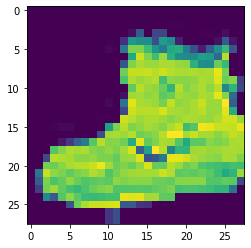

In [48]:
# Lets plot
plt.imshow(img.permute(1,2,0))

In [49]:
sample[1]

9

Well, initial prediction was Class 5, it was class 9 actually :(,

No worry, it was just random guess by model

# Device selection

As we are using GPU, so below code will help us to access GPU at different stage of Processing



In [50]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [51]:
device = get_default_device()
device

device(type='cuda')

In [52]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ConvNet(
  (residual_block1): ResidualBlock(
    (block): Sequential(
      (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(4, 8, kernel_size=(1, 1), stride=(1, 1))
    )
    (shortcut): Sequential(
      (0): Conv2d(1, 8, kernel_size=(1, 1), stride=(2, 2))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (residual_block2): ResidualBlock(
    (block): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
    )
    (shortcut): Sequential(
      (0): Conv2d(8, 32, kernel_size=(1, 1), stride=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track

# Helper Function to Get Best Fit

In [53]:
def loss_batch(model, loss_func, x, y, opt = None, metric = None):
    
    pred = model(x)
    
    loss = loss_func(pred, y)
    
    if opt is not None:
        
        loss.backward()
        opt.step()
        opt.zero_grad()
        
    metric_result = None
    
    if metric is not None:
        
        metric_result = metric(pred, y)
        
    return loss.item(), len(x), metric_result

In [54]:
def evaluate(model, loss_fn, val_dl, metric = None):
    
    with torch.no_grad():
        
        results = [loss_batch(model, loss_fn, x, y, metric = metric) for x, y in val_dl]
        
        losses, nums, metrics = zip(*results)
        
        total = np.sum(nums)
        
        avg_loss = np.sum(np.multiply(losses, nums)) / total
        
        avg_metric = None
        
        if metric is not None:
            avg_metric = np.sum(np.multiply(metrics, nums)) / total
            
    return avg_loss, total, avg_metric

# Define Fit Function

In [55]:
def fit(epochs, model, loss_fn, train_dl, val_dl, opt_fn = None, lr = None, metric = None):
    
    train_losses, val_losses, val_metrics = [], [], []
    history = []
    
    if opt_fn is None: opt_fn = torch.optim.Adam
        
    opt = opt_fn(model.parameters(), lr = lr)
    
    for epoch in range(epochs):
        
        model.train()
        for x, y in train_dl:
            train_loss, _, _ = loss_batch(model, loss_fn, x, y, opt)
            
        model.eval()
        result = evaluate(model, loss_fn, val_dl, metric)
        val_loss, total, val_metric = result
        history.append(result)
        
        train_losses.append(train_loss)
        val_losses.append(val_losses)
        val_metrics.append(val_metric)
        
        if metric is None:
            print('Epoch{}/{}, train_loss: {:.4f}, val_loss: {:.4f}' 
                 .format(epoch+1, epochs, train_loss, val_loss))
            
        else:
            print('Epoch {}/{}, train_loss: {:.4f}, val_loss: {:.4f}, val_{}: {:.4f}'
                 .format(epoch+1, epochs, train_loss, val_loss, metric.__name__, val_metric))
            
    return train_losses, val_losses, val_metrics

In [56]:
# Define accuracy as measure of perfomance
def accuracy(output, labels):
    _, preds = torch.max(output, dim = 1)
    
    return torch.sum(preds == labels).item() / len(preds)

In [57]:
# let's check how initial guess work on Validation set
val_loss, _, val_acc = evaluate(model, F.cross_entropy, val_dl, metric = accuracy)

print(val_loss, val_acc)

2.3414873352050782 0.13958333333333334


Well, around 10% accuracy, well it was initial guess, dont worry !!



Let's Train Model



In [74]:
num_epochs = 15
opt_fn = torch.optim.Adam
lr = 1e-5

In [75]:
history = fit(num_epochs, model, F.cross_entropy, train_dl, val_dl, opt_fn, lr, accuracy)

Epoch 1/15, train_loss: 0.2843, val_loss: 0.3650, val_accuracy: 0.8676
Epoch 2/15, train_loss: 0.3682, val_loss: 0.3652, val_accuracy: 0.8660
Epoch 3/15, train_loss: 0.3067, val_loss: 0.3646, val_accuracy: 0.8679
Epoch 4/15, train_loss: 0.3686, val_loss: 0.3621, val_accuracy: 0.8688
Epoch 5/15, train_loss: 0.3592, val_loss: 0.3608, val_accuracy: 0.8668
Epoch 6/15, train_loss: 0.3417, val_loss: 0.3665, val_accuracy: 0.8688
Epoch 7/15, train_loss: 0.2636, val_loss: 0.3700, val_accuracy: 0.8652
Epoch 8/15, train_loss: 0.3331, val_loss: 0.3647, val_accuracy: 0.8702
Epoch 9/15, train_loss: 0.3704, val_loss: 0.3631, val_accuracy: 0.8662
Epoch 10/15, train_loss: 0.4028, val_loss: 0.3639, val_accuracy: 0.8659
Epoch 11/15, train_loss: 0.3565, val_loss: 0.3639, val_accuracy: 0.8681
Epoch 12/15, train_loss: 0.3871, val_loss: 0.3558, val_accuracy: 0.8718
Epoch 13/15, train_loss: 0.3459, val_loss: 0.3663, val_accuracy: 0.8672
Epoch 14/15, train_loss: 0.3719, val_loss: 0.3667, val_accuracy: 0.8680
E

# Test dataloading & Model Evaluation

In [76]:
def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds  = torch.max(yb, dim=1)
    return preds[0].item()

Label: 9 , Predicted: 9


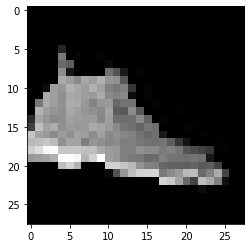

In [77]:
img, label = test_set[0]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))

Label: 9 , Predicted: 9


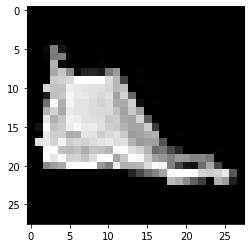

In [78]:
img, label = test_set[1839]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))

Label: 6 , Predicted: 6


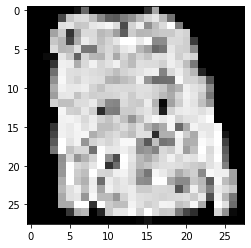

In [79]:
img, label = test_set[193]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))

Label: 4 , Predicted: 4


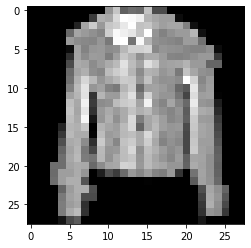

In [80]:
img, label = test_set[10]
plt.imshow(img[0], cmap='gray')
print('Label:', label, ', Predicted:', predict_image(img, model))

As a final step, let's also look at the overall loss and accuracy of the model on the test set.



In [81]:
test_loader = DeviceDataLoader(DataLoader(test_set, batch_size=256), device)
result = evaluate(model, F.cross_entropy, test_loader, metric = accuracy)
result
Accuracy = result[2] * 100
Accuracy
loss = result[0]
print("Total Losses: {}, Accuracy: {}".format(loss, Accuracy))

Total Losses: 0.37355989651679994, Accuracy: 86.45


Thats it for this Notebook...

If you like this kindly Consider Upvoting!! Happy learning!!